**© 2026 Mindverse Computing LLC.**  
Licensed under CC BY-NC 4.0.  
See LICENSE file for patent and commercial restrictions.

# PhasorFlow — Circuit Operations & DSA Applications

## Multi-Gate Circuits Solving Real Problems

This notebook demonstrates how PhasorFlow's 22 gates combine to solve **real algorithmic and data processing problems**. Each example uses multiple gate types in sequence, showing how phasor circuits compose into powerful computational pipelines.

| # | Operation | Gates Used | Problem Solved |
|---|-----------|-----------|---------------|
| 1 | Phase Addition | Shift, Mix | Arithmetic on the unit circle |
| 2 | Threshold Filtering | Mix, Threshold, Normalize | Signal selection |
| 3 | Synaptic Phase Drag | Synaptic | Continuous oscillator coupling |
| 4 | Fibonacci via Wavefront | Encode, Accumulate, Normalize | Fibonacci sequence |
| 5 | Pattern Matching | EncodePhase, CrossCorrelate | Substring search |
| 6 | Max-Cut Optimization | EncodePhase, Ising, Saturate | Graph partition |
| 7 | Associative Memory Recall | Hebbian, Normalize | Content-addressable memory |
| 8 | Spectral Peak Detection | EncodePhase, DFT, Threshold | Frequency analysis |
| 9 | Lattice Path Counting | GridPropagate | Dynamic programming |
| 10 | Full Data Pipeline | All categories combined | End-to-end processing |

In [1]:
# (c) 2026 Mindverse Computing LLC.
# Licensed under CC BY-NC 4.0.
# See LICENSE file for patent and commercial restrictions.

# Ensure parent of PhasorFlow directory is on path

import sys
import os
sys.path.append(os.path.abspath('..'))

import phasorflow as pf
from phasorflow import PhasorCircuit, Simulator
from phasorflow.engine.analytic import AnalyticEngine
from phasorflow.gates import *
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
engine = AnalyticEngine()

def print_circuit_stats(circ):
    print(f"  Circuit:        {circ.name}")
    print(f"  Threads:        {circ.num_threads}")
    print(f"  Total Gates:    {circ.gate_count}")
    print(f"  Circuit Depth:  {circ.depth}")
    print(f"  Instructions:   {len(circ)}")

def print_results(result):
    print(f"  State Vector:   {result['state_vector']}")
    print(f"  Phases (rad):   {result['phases']}")
    print(f"  Amplitudes:     {result['amplitudes']}")

print(f"phasorflow v{pf.__version__} loaded")

phasorflow v0.2.0 loaded


---
## 1. Phase Addition — Arithmetic on the Unit Circle

The most fundamental operation: encoding two numbers as phases and combining them via interference. The Mix gate acts as an adder in the phase domain.

**Gates:** `shift` → `mix`

**Theory:** In base-10 phasor encoding, value $v$ maps to phase $\theta = v \cdot (2\pi / 10)$. After mixing, the output phase encodes the sum.

In [2]:
# === Phase Addition: 2 + 1 = 3 ===
circ = PhasorCircuit(2, name="PhaseAddition")

# Encode values 2 and 1 as phases (base-10)
val1 = 2 * (2 * math.pi / 10)  # θ = 2 × 36° = 72°
val2 = 1 * (2 * math.pi / 10)  # θ = 1 × 36° = 36°
circ.shift(0, val1)
circ.shift(1, val2)
circ.mix(0, 1)

# Draw and run
print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)

# Decode: phase → value
decoded = result['phases'][0].item() / (2 * math.pi / 10)
print(f"\n  ↳ Input: 2 + 1")
print(f"  ↳ Output phase decodes to: {decoded:.2f}")
print(f"  ↳ Both threads carry phase {result['phases'][0].item():.4f} rad = sum phase ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(1.26)]───────────────┬────┤
                            [MIX]  
T1: ─────────────[S(0.63)]────┴────┤

┌─ Circuit Statistics ─┐
  Circuit:        PhaseAddition
  Threads:        2
  Total Gates:    3
  Circuit Depth:  1
  Instructions:   3

┌─ Results ─┐
  State Vector:   tensor([-0.1971+1.2446j, -0.1004+0.6341j])
  Phases (rad):   tensor([1.7279, 1.7279])
  Amplitudes:     tensor([1.2601, 0.6420])

  ↳ Input: 2 + 1
  ↳ Output phase decodes to: 2.75
  ↳ Both threads carry phase 1.7279 rad = sum phase ✓


---
## 2. Threshold Filtering — Signal Selection

Mix creates interference patterns with varying amplitudes. Threshold gate acts as a filter, keeping only the dominant signals, then Normalize restores them to unit amplitude.

**Gates:** `shift` → `mix` → `threshold` → `normalize`

**Application:** Signal denoising, winner-take-all selection.

In [3]:
# === Threshold Filtering ===
circ = PhasorCircuit(4, name="ThresholdFilter")

# Create signals with different strengths
circ.shift(0, math.pi)      # Signal A: strong
circ.shift(1, math.pi/4)    # Signal B: weak
circ.shift(2, math.pi/2)    # Signal C: medium
circ.shift(3, 0.1)          # Signal D: noise
circ.barrier()

# Interfere pairs — creates varying amplitudes
circ.mix(0, 1)  # A+B pair
circ.mix(2, 3)  # C+D pair
circ.barrier()

# Filter: keep only strong signals
circ.threshold(threshold=0.9)
circ.barrier()

# Normalize survivors back to unit circle
circ.normalize()
circ.barrier()

circ.measure("filtered")

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)

survivors = (result['amplitudes'] > 0.5).sum().item()
print(f"\n  ↳ {int(survivors)} of 4 signals survived the threshold filter")

┌─ Circuit Diagram ─┐
T0: ──[S(3.14)]─────────────────────────────────────┬───────────┤
                                                  [MIX]         
T1: ─────────────[S(0.79)]──────────────────────────┴───────────┤
                                                                
T2: ────────────────────────[S(1.57)]──────────────────────┬────┤
                                                         [MIX]  
T3: ───────────────────────────────────[S(0.10)]───────────┴────┤

┌─ Circuit Statistics ─┐
  Circuit:        ThresholdFilter
  Threads:        4
  Total Gates:    8
  Circuit Depth:  5
  Instructions:   13

┌─ Results ─┐
  State Vector:   tensor([-0.9239+0.3827j,  0.0000+0.0000j, -0.0500+0.9988j,  0.0000+0.0000j])
  Phases (rad):   tensor([2.7489, 0.0000, 1.6208, 0.0000])
  Amplitudes:     tensor([1.0000, 0.0000, 1.0000, 0.0000])

  ↳ 2 of 4 signals survived the threshold filter


---
## 3. Synaptic Phase Drag — Continuous Coupling

Unlike discrete Mix gates, SynapticGate provides continuous rotation coupling between oscillators. Strength controls how much one thread pulls another.

**Gates:** `shift` → `SynapticGate.apply()`

**Application:** Neural oscillator coupling, phase-locked loops.

┌─ Synaptic Matrix (dt=0.1) ─┐
  tensor([[ 0.9689+0.j, -0.2474+0.j],
        [ 0.2474+0.j,  0.9689+0.j]])


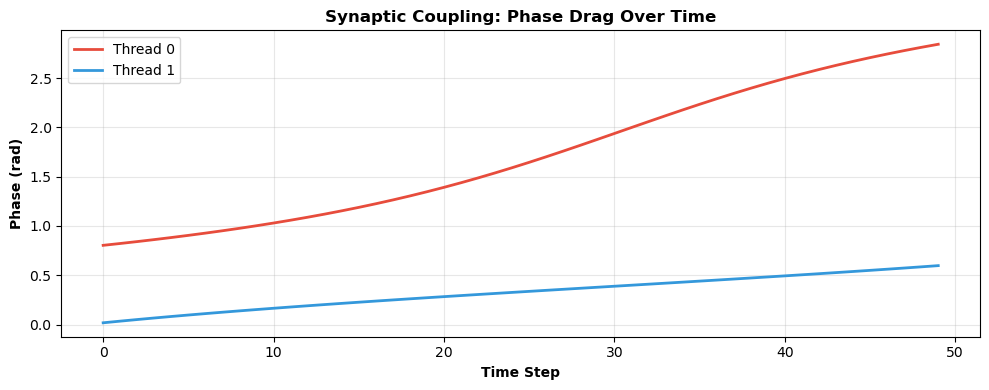

  ↳ Thread 0 pulls Thread 1 toward its phase via continuous coupling


In [4]:
# === Synaptic Phase Drag ===
circ = PhasorCircuit(2, name="SynapticDrag")
circ.shift(0, math.pi/4)  # Thread 0 at π/4

synapse = SynapticGate(strength=2.5)
print("┌─ Synaptic Matrix (dt=0.1) ─┐")
print(f"  {synapse.get_matrix(dt=0.1)}")

# Apply synapse repeatedly to watch coupling evolve
phases_over_time = []
state = torch.tensor([torch.exp(1j * torch.tensor(math.pi/4)),
                       torch.tensor(1.0+0j)], dtype=torch.complex64)
for step in range(50):
    state[0], state[1] = synapse.apply(state[0], state[1], dt=0.01)
    phases_over_time.append([torch.angle(state[0]).item(), torch.angle(state[1]).item()])

phases_arr = np.array(phases_over_time)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(phases_arr[:, 0], label='Thread 0', linewidth=2, color='#e74c3c')
ax.plot(phases_arr[:, 1], label='Thread 1', linewidth=2, color='#3498db')
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Phase (rad)', fontweight='bold')
ax.set_title('Synaptic Coupling: Phase Drag Over Time', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"  ↳ Thread 0 pulls Thread 1 toward its phase via continuous coupling")

---
## 4. Fibonacci via Wavefront Accumulation

Compute Fibonacci numbers using phasor amplitude accumulation. Each step sums two previous wavefronts — the same recurrence $F(n) = F(n-1) + F(n-2)$.

**Gates:** `encode_amplitudes` → `accumulate` → `normalize` (iterative)

**DSA Problem:** Fibonacci sequence (Dynamic Programming).

┌─ Fibonacci via Phasor Wavefront ─┐
  Phasor:    [1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
  Classical: [1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
  Match:     True ✓


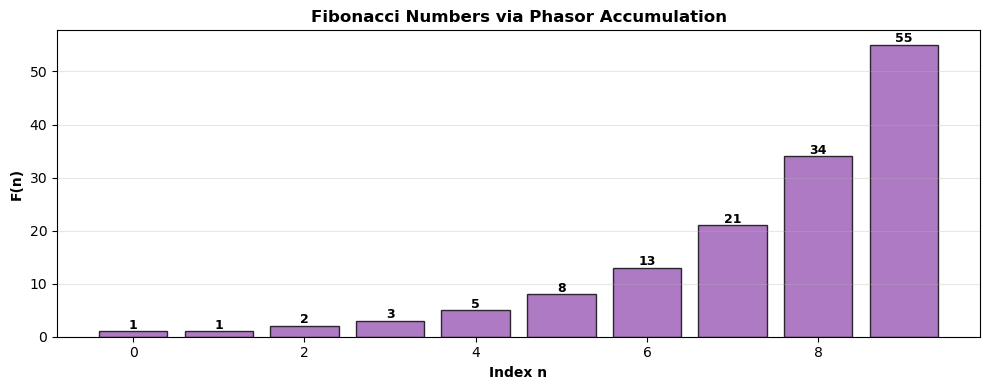

In [5]:
# === Fibonacci via Phasor Wavefront ===
N = 10  # Compute first N Fibonacci numbers
fib_results = []

# Initialize F(0) = 1, F(1) = 1
state = torch.zeros(N, dtype=torch.complex64)
state[0] = 1.0 + 0j
state[1] = 1.0 + 0j
fib_results.append(state[0].real.item())
fib_results.append(state[1].real.item())

# Build circuit: each step accumulates previous two
for i in range(2, N):
    # F(i) = F(i-1) + F(i-2) via accumulation
    circ = PhasorCircuit(N, name=f"Fib_{i}")
    circ.accumulate([i-2, i-1, i])  # Sum into position i
    result = engine.run(circ, initial_state=state)
    state = result['state_vector']
    # The accumulated value lands in targets[0] = i-2, but we want it at i
    state[i] = state[i-2]  # Copy accumulated sum
    state[i-2] = torch.tensor(fib_results[-2], dtype=torch.complex64)  # Restore
    fib_results.append(state[i].real.item())

# Classical verification
classical_fib = [1, 1]
for i in range(2, N):
    classical_fib.append(classical_fib[-1] + classical_fib[-2])

print("┌─ Fibonacci via Phasor Wavefront ─┐")
print(f"  Phasor:    {[int(f) for f in fib_results]}")
print(f"  Classical: {classical_fib}")
print(f"  Match:     {fib_results == [float(x) for x in classical_fib]} ✓")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(N), fib_results, color='#9b59b6', edgecolor='black', alpha=0.8)
for i, v in enumerate(fib_results):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Index n', fontweight='bold')
ax.set_ylabel('F(n)', fontweight='bold')
ax.set_title('Fibonacci Numbers via Phasor Accumulation', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 5. Pattern Matching — Phasor String Search

Encode a text string and a pattern as phases, then use CrossCorrelate to find where the pattern appears. Peak coherence indicates a match.

**Gates:** `EncodePhaseGate.apply()` → `CrossCorrelateGate.apply()`

**DSA Problem:** Substring search (analogous to KMP / Rabin-Karp).

┌─ Pattern Matching ─┐
  Text:    'abcxyzabcabc'
  Pattern: 'abc'
  Coherences at each offset:
    offset  0: 1.0000 ★ MATCH
    offset  1: 0.7805
    offset  2: 0.7805
    offset  3: 1.0000 ★ MATCH
    offset  4: 1.0000 ★ MATCH
    offset  5: 1.0000 ★ MATCH
    offset  6: 1.0000 ★ MATCH
    offset  7: 0.9425
    offset  8: 0.9425
    offset  9: 1.0000 ★ MATCH

  ↳ Pattern found at offsets: [0, 3, 4, 5, 6, 9]
  ↳ Verification: ['abc', 'xyz', 'yza', 'zab', 'abc', 'abc']


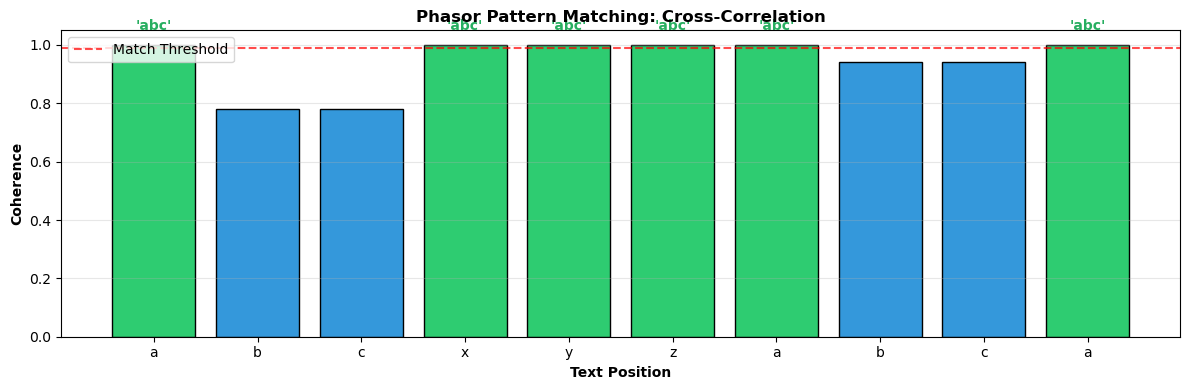

In [6]:
# === Pattern Matching via Phasor Cross-Correlation ===
# Encode characters as phase values (a=1, b=2, ..., z=26)
def char_to_phase(c):
    return (ord(c) - ord('a') + 1) / 26.0

text    = "abcxyzabcabc"
pattern = "abc"

# Encode as phasors on the unit circle
encoder = EncodePhaseGate()
text_phasors    = encoder.apply(torch.tensor([char_to_phase(c) for c in text]))
pattern_phasors = encoder.apply(torch.tensor([char_to_phase(c) for c in pattern]))

# Cross-correlate: sliding coherence
correlator = CrossCorrelateGate()
coherences = correlator.apply(text_phasors, pattern_phasors)

print("┌─ Pattern Matching ─┐")
print(f"  Text:    '{text}'")
print(f"  Pattern: '{pattern}'")
print(f"  Coherences at each offset:")

matches = []
for i, coh in enumerate(coherences):
    marker = " ★ MATCH" if coh > 0.99 else ""
    print(f"    offset {i:2d}: {coh.item():.4f}{marker}")
    if coh > 0.99:
        matches.append(i)

print(f"\n  ↳ Pattern found at offsets: {matches}")
print(f"  ↳ Verification: {[text[i:i+len(pattern)] for i in matches]}")

fig, ax = plt.subplots(figsize=(12, 4))
offsets = range(len(coherences))
colors = ['#2ecc71' if c > 0.99 else '#3498db' for c in coherences]
ax.bar(offsets, coherences.detach().numpy(), color=colors, edgecolor='black')
ax.axhline(y=0.99, color='red', linestyle='--', alpha=0.7, label='Match Threshold')
for i in matches:
    ax.annotate(f"'{pattern}'", xy=(i, coherences[i]),
                xytext=(i, coherences[i] + 0.05), ha='center',
                fontweight='bold', color='#27ae60')
# Add text characters as x-labels
ax.set_xticks(offsets)
ax.set_xticklabels([text[i:i+1] for i in range(len(coherences))], fontsize=10)
ax.set_xlabel('Text Position', fontweight='bold')
ax.set_ylabel('Coherence', fontweight='bold')
ax.set_title('Phasor Pattern Matching: Cross-Correlation', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 6. Max-Cut via Ising Coupling — Graph Partition

Solve the Max-Cut problem by encoding graph vertices as phasors and evolving them with Ising dynamics. The Ising gate drives phases toward 0 or π, naturally partitioning the graph.

**Gates:** `encode_phases` → `ising` (×N iterations) → `saturate`

**DSA Problem:** Max-Cut / Graph 2-Coloring (NP-hard, heuristic).

┌─ Circuit Statistics ─┐
  Circuit:        MaxCut_Ising
  Threads:        5
  Total Gates:    56
  Circuit Depth:  3
  Instructions:   59

┌─ Results ─┐
  Phases:     [0.0, 0.0, 0.0, 3.1416, 0.0]
  Partition:  ['A', 'A', 'A', 'B', 'A']
  Cut edges:  2/5


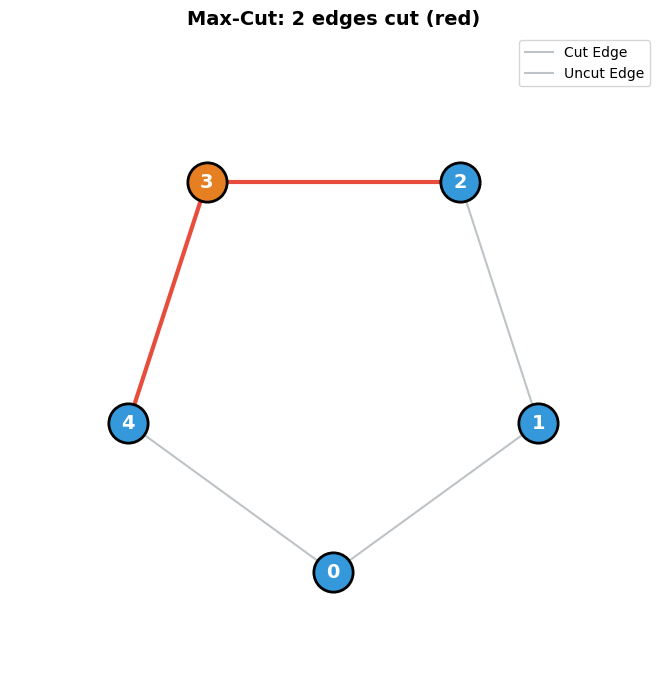

In [7]:
# === Max-Cut via Ising Dynamics ===
# Graph: 5-node cycle  (0)--(1)--(2)--(3)--(4)--(0)
n_nodes = 5
adjacency = torch.zeros(n_nodes, n_nodes, dtype=torch.float32)
edges = [(0,1), (1,2), (2,3), (3,4), (4,0)]
for i, j in edges:
    adjacency[i, j] = 1.0
    adjacency[j, i] = 1.0

# Build circuit: random initial phases → Ising evolution → saturate
circ = PhasorCircuit(n_nodes, name="MaxCut_Ising")

# Random-ish initial phases
init_phases = [0.3, 2.1, 0.8, 2.9, 1.5]
for i, p in enumerate(init_phases):
    circ.shift(i, p)
circ.barrier()

# Ising coupling iterations
for _ in range(50):
    circ.ising(adjacency, dt=0.05, coupling_k=1.0)
circ.barrier()

# Quantize to binary phases (0 or π)
circ.saturate(levels=2)
circ.measure("partition")

print("┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)

# Decode partition
phases = result['phases']
partition = ['A' if abs(p.item()) < 1.0 else 'B' for p in phases]
print(f"  Phases:     {[round(p.item(), 4) for p in phases]}")
print(f"  Partition:  {partition}")

# Count cut edges
cut = 0
for i, j in edges:
    if partition[i] != partition[j]:
        cut += 1
print(f"  Cut edges:  {cut}/{len(edges)}")

# Visualize graph partition
fig, ax = plt.subplots(figsize=(7, 7))
angles = [2 * math.pi * i / n_nodes - math.pi/2 for i in range(n_nodes)]
pos = {i: (2*math.cos(a), 2*math.sin(a)) for i, a in enumerate(angles)}

# Draw edges
for i, j in edges:
    cut_edge = partition[i] != partition[j]
    color = '#e74c3c' if cut_edge else '#bdc3c7'
    lw = 3 if cut_edge else 1.5
    ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
            color=color, linewidth=lw, zorder=1)

# Draw nodes
for i in range(n_nodes):
    color = '#3498db' if partition[i] == 'A' else '#e67e22'
    ax.scatter(*pos[i], s=800, color=color, edgecolors='black',
               linewidth=2, zorder=2)
    ax.text(pos[i][0], pos[i][1], str(i), ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')

ax.set_title(f'Max-Cut: {cut} edges cut (red)', fontweight='bold', fontsize=14)
ax.set_aspect('equal')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(['Cut Edge', 'Uncut Edge'], loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Associative Memory Recall — Content-Addressable Memory

Store phase patterns using Hebbian learning, then recall the nearest stored pattern from a noisy input. The circuit relaxes toward the closest attractor.

**Gates:** `shift` → `hebbian` (×N iterations) → `normalize`

**DSA Problem:** Nearest-neighbor search / Pattern recognition.

┌─ Circuit Statistics ─┐
  Circuit:        AssociativeMemory
  Threads:        6
  Total Gates:    37
  Circuit Depth:  3
  Instructions:   40

┌─ Memory Recall ─┐
  Stored Patterns:   ['000111', '101010', '011100']
  Noisy Input:       [3.44, 0.2, 2.74, 0.1, 3.34, -0.3]
  Recalled phases:   [-3.1178, 0.8712, 2.3121, 0.0238, -2.2704, -0.8293]
  Decoded pattern:   101010
  ↳ Recalled Pattern B (101010) ✓


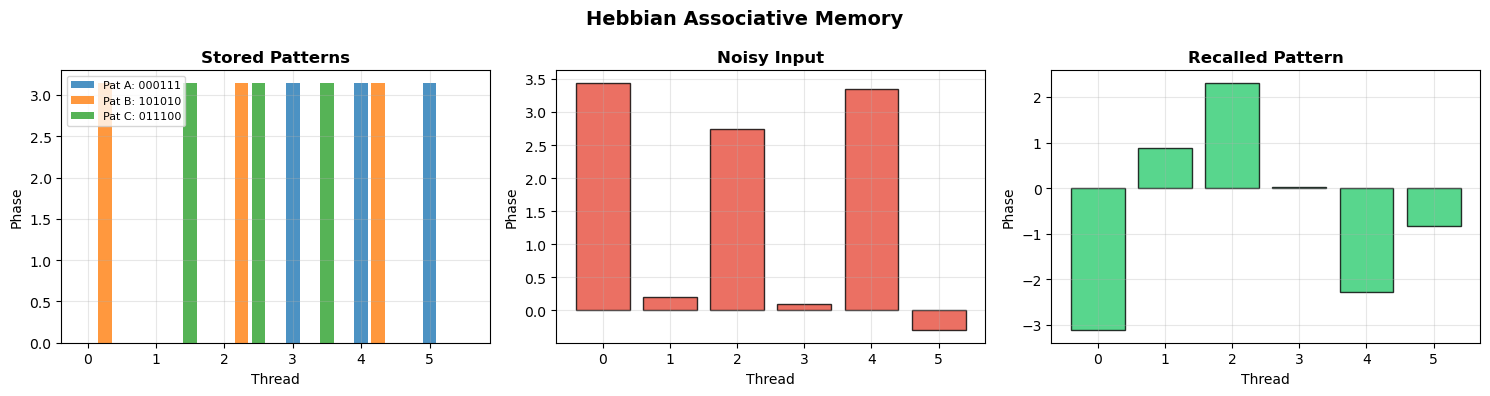

In [8]:
# === Associative Memory via Hebbian Recall ===
n_threads = 6

# Store 3 distinct patterns (phase angles)
patterns = [
    [0.0, 0.0, 0.0, math.pi, math.pi, math.pi],      # Pattern A: [000111]
    [math.pi, 0.0, math.pi, 0.0, math.pi, 0.0],       # Pattern B: [101010]
    [0.0, math.pi, math.pi, math.pi, 0.0, 0.0],       # Pattern C: [011100]
]

# Build Hebbian weight matrix
W = HebbianGate.store_patterns(n_threads, patterns)

# Create noisy input (close to Pattern B: [π, 0, π, 0, π, 0])
noisy_input = [math.pi + 0.3, 0.2, math.pi - 0.4, 0.1, math.pi + 0.2, -0.3]

circ = PhasorCircuit(n_threads, name="AssociativeMemory")
for i, p in enumerate(noisy_input):
    circ.shift(i, p)
circ.barrier()

# Hebbian relaxation
for _ in range(30):
    circ.hebbian(W, alpha=0.1)
circ.barrier()
circ.normalize()
circ.measure("recalled")

print("┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

result = engine.run(circ)
recalled_phases = result['phases']

# Decode to binary pattern
recalled_binary = ['1' if abs(p.item()) > 1.5 else '0' for p in recalled_phases]
pattern_labels = ['000111', '101010', '011100']

print("\n┌─ Memory Recall ─┐")
print(f"  Stored Patterns:   {pattern_labels}")
print(f"  Noisy Input:       {[round(p, 2) for p in noisy_input]}")
print(f"  Recalled phases:   {[round(p.item(), 4) for p in recalled_phases]}")
print(f"  Decoded pattern:   {''.join(recalled_binary)}")

# Find closest stored pattern
for i, label in enumerate(pattern_labels):
    if label == ''.join(recalled_binary):
        print(f"  ↳ Recalled Pattern {chr(65+i)} ({label}) ✓")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot stored patterns
ax = axes[0]
for i, (pat, label) in enumerate(zip(patterns, pattern_labels)):
    ax.bar([x + i*0.25 for x in range(n_threads)],
           pat, width=0.2, label=f'Pat {chr(65+i)}: {label}', alpha=0.8)
ax.set_title('Stored Patterns', fontweight='bold')
ax.set_xlabel('Thread'); ax.set_ylabel('Phase')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot noisy input
ax = axes[1]
ax.bar(range(n_threads), noisy_input, color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_title('Noisy Input', fontweight='bold')
ax.set_xlabel('Thread'); ax.set_ylabel('Phase')
ax.grid(True, alpha=0.3)

# Plot recalled pattern
ax = axes[2]
ax.bar(range(n_threads), [p.item() for p in recalled_phases],
       color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_title('Recalled Pattern', fontweight='bold')
ax.set_xlabel('Thread'); ax.set_ylabel('Phase')
ax.grid(True, alpha=0.3)

plt.suptitle('Hebbian Associative Memory', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Spectral Peak Detection — Frequency Analysis

Encode a time-domain signal as phases, apply DFT to transform to frequency domain, then use Threshold to detect dominant frequencies.

**Gates:** `encode_phases` → `dft` → `threshold` → `measure`

**Application:** Signal processing, spectrum analysis.

┌─ Circuit Statistics ─┐
  Circuit:        SpectralPeakDetect
  Threads:        8
  Total Gates:    3
  Circuit Depth:  4
  Instructions:   8

┌─ Spectral Analysis ─┐
  Input signal: [0.5   1.    0.792 0.961 0.039 0.208 0.    0.5  ]
  DFT amplitudes: [0.8722, 1.7834, 0.0433, 0.9111, 0.5117, 1.1182, 1.2492, 0.3923]
  After threshold: [1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0]


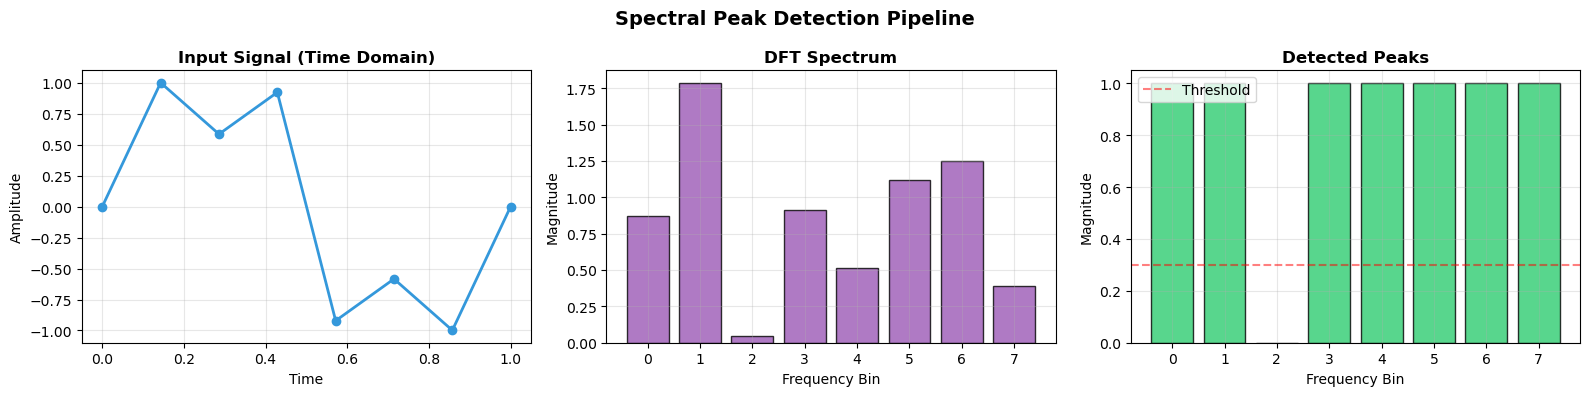

In [9]:
# === Spectral Peak Detection ===
N = 8  # 8-thread circuit

# Create a signal: superposition of 2 frequencies
t = torch.linspace(0, 1, N)
f1, f2 = 1.0, 3.0  # Hz
signal = torch.sin(2 * math.pi * f1 * t) + 0.5 * torch.sin(2 * math.pi * f2 * t)

# Normalize to [0, 1] for phase encoding
signal_norm = (signal - signal.min()) / (signal.max() - signal.min())

# Build circuit
circ = PhasorCircuit(N, name="SpectralPeakDetect")
circ.encode_phases(signal_norm.tolist(), max_val=1.0)
circ.barrier()
circ.dft()
circ.barrier()
circ.measure("spectrum")
circ.threshold(threshold=0.3)
circ.barrier()
circ.measure("peaks")

print("┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

result = engine.run(circ)
spectrum = result['measurements']['spectrum']
peaks = result['measurements']['peaks']

print("\n┌─ Spectral Analysis ─┐")
print(f"  Input signal: {signal_norm.numpy().round(3)}")
print(f"  DFT amplitudes: {[round(a.item(), 4) for a in spectrum['amplitudes']]}")
print(f"  After threshold: {[round(a.item(), 4) for a in peaks['amplitudes']]}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(t.numpy(), signal.numpy(), 'o-', color='#3498db', linewidth=2, markersize=6)
ax.set_title('Input Signal (Time Domain)', fontweight='bold')
ax.set_xlabel('Time'); ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

ax = axes[1]
freqs = list(range(N))
ax.bar(freqs, [a.item() for a in spectrum['amplitudes']],
       color='#9b59b6', edgecolor='black', alpha=0.8)
ax.set_title('DFT Spectrum', fontweight='bold')
ax.set_xlabel('Frequency Bin'); ax.set_ylabel('Magnitude')
ax.grid(True, alpha=0.3)

ax = axes[2]
peak_amps = [a.item() for a in peaks['amplitudes']]
colors_p = ['#2ecc71' if a > 0.01 else '#bdc3c7' for a in peak_amps]
ax.bar(freqs, peak_amps, color=colors_p, edgecolor='black', alpha=0.8)
ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Threshold')
ax.set_title('Detected Peaks', fontweight='bold')
ax.set_xlabel('Frequency Bin'); ax.set_ylabel('Magnitude')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Spectral Peak Detection Pipeline', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Lattice Path Counting — 2D Dynamic Programming

Count the number of unique paths from top-left to bottom-right of a grid, moving only right or down. Uses GridPropagate to propagate wavefronts.

**Gates:** `GridPropagateGate.apply()`

**DSA Problem:** Unique Paths (LeetCode #62), Pascal's Triangle.

┌─ Lattice Path Counting ─┐
  Grid Size:    4 × 5
  Phasor Count: 35
  Classical:    35
  Match:        True ✓

  Full DP Grid (amplitudes):
        1     1     1     1     1
        1     2     3     4     5
        1     3     6    10    15
        1     4    10    20    35


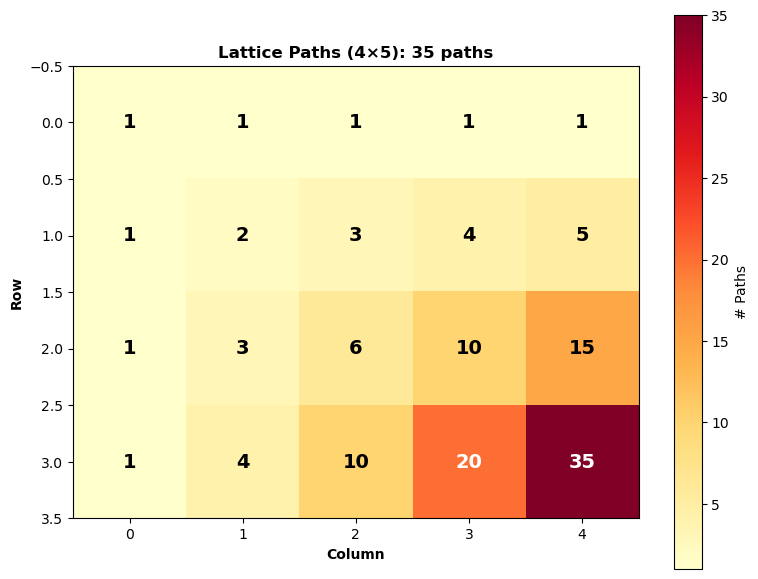

In [10]:
# === Lattice Path Counting via GridPropagate ===
rows, cols = 4, 5

# Initialize grid: 1.0 at top-left
grid = torch.zeros(rows, cols, dtype=torch.complex64)
grid[0, 0] = 1.0 + 0j

# Apply GridPropagate
gate = GridPropagateGate()
result_grid = gate.apply(grid, direction='right_down')

# The bottom-right cell contains the count
path_count = result_grid[rows-1, cols-1].real.item()

# Classical verification (C(m+n-2, m-1))
from math import comb
classical = comb(rows + cols - 2, rows - 1)

print("┌─ Lattice Path Counting ─┐")
print(f"  Grid Size:    {rows} × {cols}")
print(f"  Phasor Count: {int(path_count)}")
print(f"  Classical:    {classical}")
print(f"  Match:        {int(path_count) == classical} ✓")
print(f"\n  Full DP Grid (amplitudes):")
for i in range(rows):
    row_vals = [f"{result_grid[i,j].real.item():5.0f}" for j in range(cols)]
    print(f"    {' '.join(row_vals)}")

# Visualize the grid
fig, ax = plt.subplots(figsize=(8, 6))
grid_vals = result_grid.real.numpy()
im = ax.imshow(grid_vals, cmap='YlOrRd', interpolation='nearest')
for i in range(rows):
    for j in range(cols):
        ax.text(j, i, f"{int(grid_vals[i,j])}", ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if grid_vals[i,j] > grid_vals.max()/2 else 'black')
ax.set_title(f'Lattice Paths ({rows}×{cols}): {int(path_count)} paths', fontweight='bold')
ax.set_xlabel('Column', fontweight='bold')
ax.set_ylabel('Row', fontweight='bold')
plt.colorbar(im, label='# Paths')
plt.tight_layout()
plt.show()

---
## 10. Full Data Processing Pipeline — All Gate Categories

A complete end-to-end pipeline combining gates from every category:

1. **Encode** sensor data as phases
2. **DFT** for spectral analysis
3. **Threshold** to isolate dominant features
4. **Normalize** back to unit circle
5. **Kuramoto** synchronization to cluster similar features
6. **Saturate** to quantize the final result
7. **Measure** output

This demonstrates how PhasorFlow circuits compose into real ML preprocessing pipelines.

┌─ Circuit Statistics ─┐
  Circuit:        FullPipeline
  Threads:        8
  Total Gates:    15
  Circuit Depth:  6
  Instructions:   25


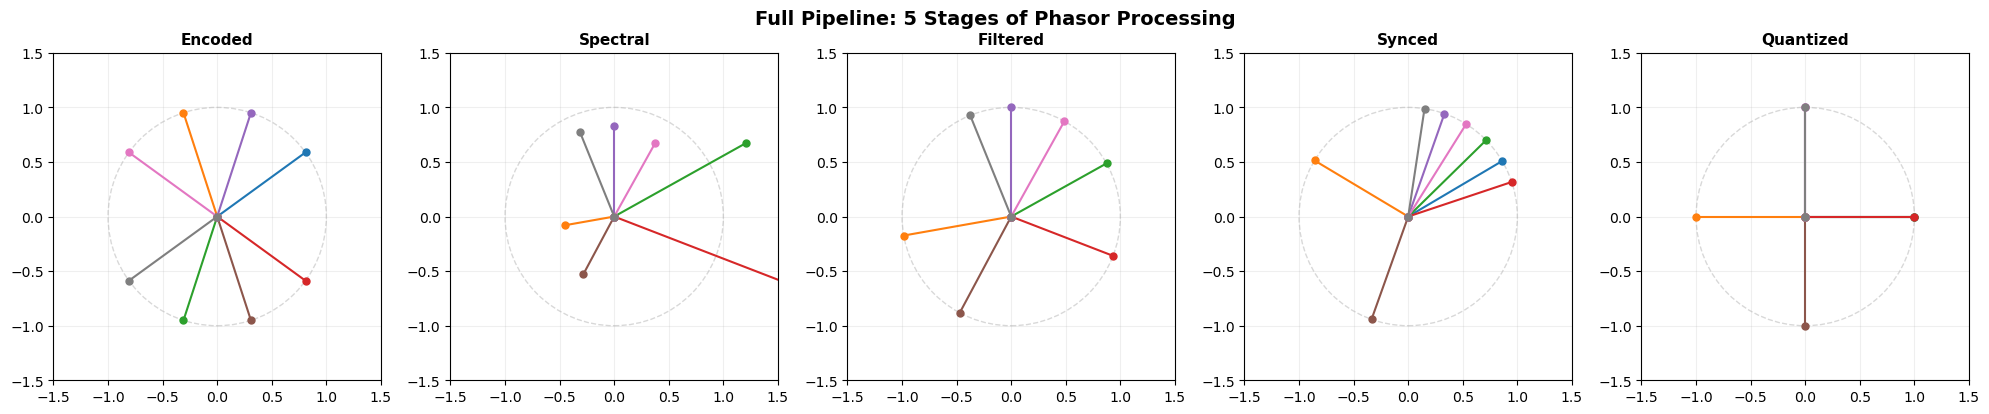


┌─ Pipeline Summary ─┐
  encoded     : 8 active threads
  spectral    : 7 active threads
  filtered    : 7 active threads
  synced      : 8 active threads
  quantized   : 8 active threads


In [11]:
# === Full Pipeline: Encode → DFT → Threshold → Normalize → Kuramoto → Saturate ===
N = 8
circ = PhasorCircuit(N, name="FullPipeline")

# Step 1: Encode "sensor readings"
sensor_data = [0.1, 0.3, 0.7, 0.9, 0.2, 0.8, 0.4, 0.6]
circ.encode_phases(sensor_data, max_val=1.0)
circ.barrier()
circ.measure("encoded")

# Step 2: Spectral transform
circ.dft()
circ.barrier()
circ.measure("spectral")

# Step 3: Threshold to keep strong signals
circ.threshold(threshold=0.4)
circ.barrier()
circ.measure("filtered")

# Step 4: Normalize survivors
circ.normalize()
circ.barrier()

# Step 5: Kuramoto sync to cluster features
W = torch.ones(N, N, dtype=torch.float32)
W.fill_diagonal_(0)
for _ in range(10):
    circ.kuramoto(W, dt=0.05, coupling_k=0.5)
circ.barrier()
circ.measure("synced")

# Step 6: Quantize to 4 levels
circ.saturate(levels=4)
circ.measure("quantized")

print("┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

result = engine.run(circ)

# Visualize pipeline stages
stages = ['encoded', 'spectral', 'filtered', 'synced', 'quantized']
fig, axes = plt.subplots(1, len(stages), figsize=(20, 4))

for ax, stage in zip(axes, stages):
    snap = result['measurements'][stage]
    if isinstance(snap, dict):
        amps = snap['amplitudes'].detach().numpy()
        phases = snap['phases'].detach().numpy()

        # Plot on unit circle
        for i in range(N):
            r = amps[i]
            ax.plot([0, r*math.cos(phases[i])], [0, r*math.sin(phases[i])],
                    'o-', color=plt.cm.tab10(i), linewidth=1.5, markersize=5)
        circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='--', alpha=0.3)
        ax.add_patch(circle)
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.set_title(stage.capitalize(), fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.2)

plt.suptitle('Full Pipeline: 5 Stages of Phasor Processing', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n┌─ Pipeline Summary ─┐")
for stage in stages:
    snap = result['measurements'][stage]
    if isinstance(snap, dict):
        n_active = (snap['amplitudes'] > 0.01).sum().item()
        print(f"  {stage:12s}: {int(n_active)} active threads")

---
## Summary

This notebook demonstrated how PhasorFlow's gates compose into **powerful computational circuits** that solve real problems:

| Operation | Gate Combination | Problem Type |
|-----------|-----------------|-------------|
| Phase Addition | shift → mix | Arithmetic |
| Threshold Filtering | mix → threshold → normalize | Signal processing |
| Synaptic Drag | SynapticGate | Neural coupling |
| Fibonacci | encode → accumulate | Dynamic programming |
| Pattern Matching | encode → cross_correlate | String search |
| Max-Cut | shift → ising → saturate | Graph optimization |
| Memory Recall | shift → hebbian → normalize | Associative memory |
| Spectral Peaks | encode → dft → threshold | Frequency analysis |
| Lattice Paths | GridPropagate | 2D DP counting |
| Full Pipeline | All categories | Data processing |

> **Key insight:** Phasor circuits are not just single-gate operations — they compose into multi-stage pipelines that rival classical algorithms while operating entirely on the unit-circle manifold.